## Load Libraries

In [2]:
# Ensure local package path is first
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import libraries
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
import importlib

# Reload to pick up code changes
import galform_analysis.analysis.correlation.correlation as corr_module
import galform_analysis.analysis.correlation.dm_correlation as dm_corr_module
import galform_analysis.analysis.correlation.plot_correlation as plot_corr_module

# Ensure we see latest code before symbol imports
importlib.reload(corr_module)
importlib.reload(dm_corr_module)
importlib.reload(plot_corr_module)

# Import updated functions after reload
from galform_analysis.analysis.correlation.plot_correlation import (
    plot_single_correlation,
    plot_correlation_multi_redshift,
    plot_avg_correlation_over_redshifts,
    plot_correlation_multi_redshift_avg_subvolumes,
)
from galform_analysis.analysis.correlation import (
    correlation_given_redshift_and_subvolume,
    dm_correlation_from_tree_file,
    avg_dm_correlation_from_tree_files,
)

base_dir = get_base_dir()

# Plotting defaults (match compare_mass_functions style)
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11


## Dark Matter Halo 2PCF from Merger Trees

In [10]:
# Compute DM halo correlation using central galaxy positions as halo centers
# P-Millennium paths for L800 box
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges (same as galaxy correlation)
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply minimum halo mass cut
mhalo_min = 1e11  # Msun

print("Computing DM halo 2PCF using central galaxies as halo centers...")
print(f"Snapshot: {example_snapshot}, Subvolume: {example_ivol}")
print(f"Galaxy output path: {snap_path}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

# Use correlation_given_redshift_and_subvolume with centrals_only=True
# This gives us the halo correlation function since each central represents a halo
dm_result = correlation_given_redshift_and_subvolume(
    iz_path=snap_path,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    centrals_only=True,  # This filters for halo centers!
    mhalo_min=mhalo_min,
)

if dm_result is not None:
    print(f"  Redshift: {dm_result['z']:.4f}")
    print(f"  N_halos: {dm_result['ngal']}")  # ngal here means number of halos
    print(f"  Boxsize: {dm_result['boxsize']:.1f} Mpc/h")
    print(f"  V_ivol: {dm_result['V_ivol']:.3e} Mpc³")
    print(f"\n  {'r [Mpc/h]':>12}  {'ξ_DM(r)':>12}")
    print("  " + "-" * 26)
    r = dm_result['r']
    xi_dm = dm_result['xi']
    for i in range(0, len(r), 2):
        if np.isfinite(xi_dm[i]):
            print(f"  {r[i]:12.2f}  {xi_dm[i]:12.6f}")
    
    # Plot the DM halo correlation function
    plt.figure(figsize=(8, 6))
    plt.loglog(r, xi_dm, 'o-', color='darkred', label=f"DM halos (z={dm_result['z']:.2f})")
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('ξ(r)', fontsize=12)
    plt.title(f'Dark Matter Halo Two-Point Correlation Function\n(z={dm_result["z"]:.2f}, N={dm_result["ngal"]}, M>={mhalo_min:.0e} Msun)', 
              fontsize=11)
    plt.grid(True, alpha=0.3, which='both')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to compute DM correlation function")


P-Millennium tree file for iz207, subvolume 100:
  Path: /cosma5/data/jch/Galform/Merger_Trees/P-Millennium/Updated_Trees/all_snaps/treedir_269/tree_269.100.hdf5
  Exists: True

Inspecting HDF5 structure...
Top-level keys: ['cosmology', 'fileInfo', 'groupFinder', 'haloTrees', 'hostIndex', 'outputTimes', 'simulation', 'treeConstruction', 'treeIndex', 'units']

Group 'cosmology' contains:

Group 'fileInfo' contains:

Group 'groupFinder' contains:

Group 'haloTrees' contains:
  angularMomentum: shape=(36224200, 3), dtype=float32
  descendantHost: shape=(36224200,), dtype=int64
  descendantIndex: shape=(36224200,), dtype=int64
  descendantSnapshot: shape=(36224200,), dtype=int32
  enclosingIndex: shape=(36224200,), dtype=int64
  fofIndex: shape=(36224200,), dtype=int32
  halfMassRadius: shape=(36224200,), dtype=float32
  hostIndex: shape=(36224200,), dtype=int64
  isDHaloCentre: shape=(36224200,), dtype=int32
  isFoFCentre: shape=(36224200,), dtype=int32
  isInterpolated: shape=(36224200,)

## Galaxy Bias: Compare Galaxy vs DM Halo Correlation

Computing galaxy 2PCF (all galaxies)...

Comparison:
  N_galaxies: 6152
  N_halos: 4198
  Ratio: 1.47 galaxies per halo



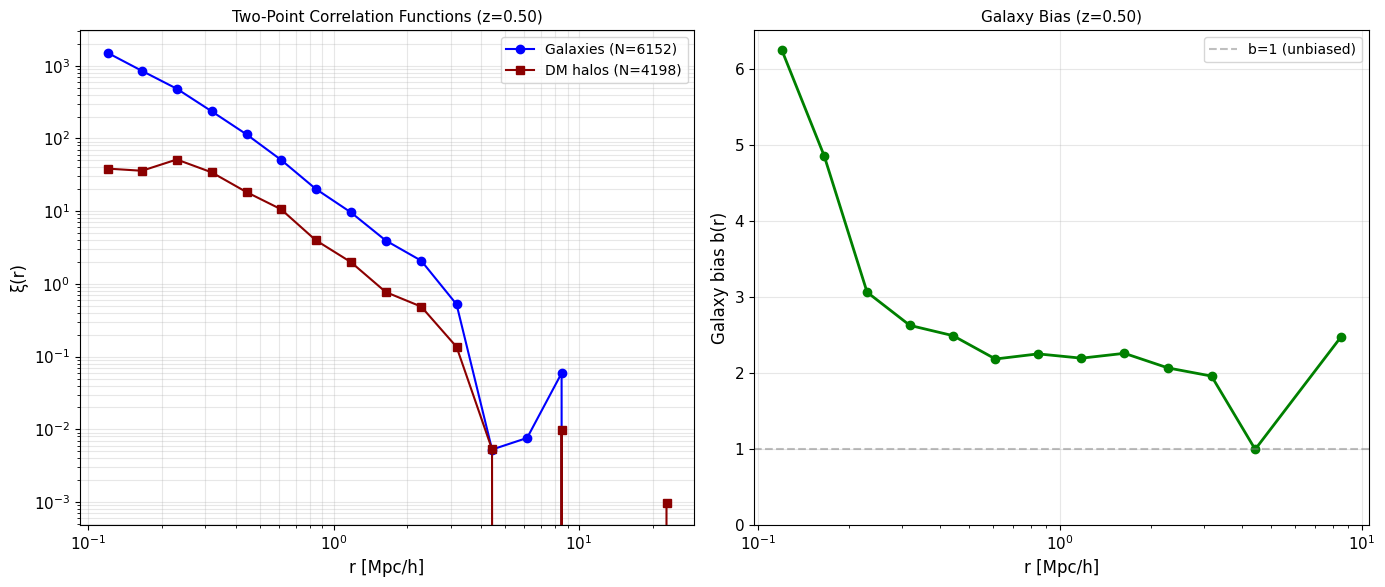

     r [Mpc/h]      ξ_gal(r)       ξ_DM(r)      bias
  --------------------------------------------------
          0.12   1502.696147     38.459321     6.251
          0.17    848.886878     35.914509     4.862
          0.23    482.045247     51.294642     3.066
          0.32    236.488674     34.224970     2.629
          0.44    113.567692     18.268052     2.493
          0.61     50.711762     10.612254     2.186
          0.85     20.260176      3.990148     2.253
          1.18      9.610138      1.991152     2.197
          1.63      3.942408      0.771333     2.261
          2.28      2.083384      0.486934     2.068
          3.17      0.523394      0.136094     1.961
          4.43      0.005281      0.005319     0.996
          8.51      0.059229      0.009680     2.474


In [8]:
# Now compute galaxy correlation (all galaxies) and compare to DM halos
print("Computing galaxy 2PCF (all galaxies)...")
gal_result = correlation_given_redshift_and_subvolume(
    iz_path=snap_path,
    ivol=example_ivol,
    rbins=rbins,
    nthreads=4,
    centrals_only=False,  # All galaxies
    mhalo_min=mhalo_min,
)

if gal_result is not None and dm_result is not None:
    print(f"\nComparison:")
    print(f"  N_galaxies: {gal_result['ngal']}")
    print(f"  N_halos: {dm_result['ngal']}")
    print(f"  Ratio: {gal_result['ngal'] / dm_result['ngal']:.2f} galaxies per halo\n")
    
    # Compute galaxy bias: b(r) = sqrt(xi_gal / xi_dm)
    r = gal_result['r']
    xi_gal = gal_result['xi']
    xi_dm = dm_result['xi']
    
    # Only compute where both are positive
    mask = (xi_gal > 0) & (xi_dm > 0)
    bias = np.full_like(xi_gal, np.nan)
    bias[mask] = np.sqrt(xi_gal[mask] / xi_dm[mask])
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left panel: Correlation functions
    ax = axes[0]
    ax.loglog(r, xi_gal, 'o-', color='blue', label=f'Galaxies (N={gal_result["ngal"]})', markersize=6)
    ax.loglog(r, xi_dm, 's-', color='darkred', label=f'DM halos (N={dm_result["ngal"]})', markersize=6)
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('ξ(r)', fontsize=12)
    ax.set_title(f'Two-Point Correlation Functions (z={gal_result["z"]:.2f})', fontsize=11)
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=10)
    
    # Right panel: Galaxy bias
    ax = axes[1]
    ax.semilogx(r[mask], bias[mask], 'o-', color='green', markersize=6, linewidth=2)
    ax.axhline(1, color='gray', linestyle='--', alpha=0.5, label='b=1 (unbiased)')
    ax.set_xlabel('r [Mpc/h]', fontsize=12)
    ax.set_ylabel('Galaxy bias b(r)', fontsize=12)
    ax.set_title(f'Galaxy Bias (z={gal_result["z"]:.2f})', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
    
    # Print bias values
    print(f"  {'r [Mpc/h]':>12}  {'ξ_gal(r)':>12}  {'ξ_DM(r)':>12}  {'bias':>8}")
    print("  " + "-" * 50)
    for i in range(len(r)):
        if mask[i]:
            print(f"  {r[i]:12.2f}  {xi_gal[i]:12.6f}  {xi_dm[i]:12.6f}  {bias[i]:8.3f}")
else:
    print("Could not compute comparison - missing results")
